**HHC, HHC-SE and HHC-GM Reports**

In [36]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

start = Path.cwd().resolve()
project_root = next(path for path in (start, *start.parents) if (path / "src" / "hhc.py").exists())
sys.path.insert(0, str(project_root))

from src.hhc import evaluate

output_dir = project_root / "outputs"
report_dir = project_root / "reports"
report_dir.mkdir(parents=True, exist_ok=True)

BACKGROUND = "#0B1120"
PANEL = "#111827"
TEXT = "#F8FAFC"
MUTED_TEXT = "#CBD5E1"
GRID_COLOR = "#334155"
METRIC_COLORS = ["#56B4E9", "#E69F00", "#009E73"]

plt.style.use("dark_background")
plt.rcParams.update(
    {
        "figure.dpi": 140,
        "savefig.dpi": 450,
        "figure.facecolor": BACKGROUND,
        "axes.facecolor": PANEL,
        "savefig.facecolor": BACKGROUND,
        "axes.edgecolor": GRID_COLOR,
        "axes.labelcolor": TEXT,
        "xtick.color": MUTED_TEXT,
        "ytick.color": MUTED_TEXT,
        "text.color": TEXT,
        "grid.color": GRID_COLOR,
        "font.size": 11,
        "font.family": "DejaVu Sans",
        "lines.antialiased": True,
    }
)

In [37]:
METHODS = ["HHC", "HHC-SE", "HHC-GM"]
prediction_files = {
    "HHC": output_dir / "hhc_predictions.csv",
    "HHC-SE": output_dir / "hhc_se_predictions.csv",
    "HHC-GM": output_dir / "hhc_gm_predictions.csv",
}
prediction_columns = {method: f"predicted_cluster_{method.lower().replace('-', '_')}" for method in METHODS}
metrics_files = {
    "HHC": output_dir / "hhc_metrics.json",
    "HHC-SE": output_dir / "hhc_se_metrics.json",
    "HHC-GM": output_dir / "hhc_gm_metrics.json",
}
run_summaries = {
    method: json.loads(path.read_text(encoding="utf-8"))
    for method, path in metrics_files.items()
}
key_columns = ["paper_id", "ambiguous_name", "label"]

frames = {}
for method, path in prediction_files.items():
    frame = pd.read_csv(path, dtype=str)
    frame["occurrence"] = frame.groupby(key_columns, dropna=False).cumcount()
    frames[method] = frame.rename(columns={"predicted_cluster": prediction_columns[method]})

join_columns = key_columns + ["occurrence"]
common = frames["HHC-GM"][join_columns + [prediction_columns["HHC-GM"]]]
for method in ("HHC", "HHC-SE"):
    common = common.merge(
        frames[method][join_columns + [prediction_columns[method]]],
        on=join_columns,
        how="inner",
        validate="one_to_one",
    )

if len(common) != len(frames["HHC-GM"]):
    raise ValueError("Some HHC-GM records do not have predictions from every method")

rows = common[["ambiguous_name", "label"]].to_dict(orient="records")
scores = {
    method: evaluate(rows, common[prediction_columns[method]].tolist())
    for method in METHODS
}
print(f"Compared {len(common):,} records from {common['ambiguous_name'].nunique():,} ambiguous-name groups.")

Compared 100 records from 9 ambiguous-name groups.


In [38]:
def metric_line_plot(metric_keys, labels, title, filename):
    x = np.arange(len(METHODS))
    colors = METRIC_COLORS
    values_by_metric = [
        np.array([scores[method][key] for method in METHODS])
        for key in metric_keys
    ]
    all_values = np.concatenate(values_by_metric)
    lower = max(0, all_values.min() - 0.055)
    upper = min(1.08, all_values.max() + 0.065)

    fig, axis = plt.subplots(figsize=(8, 5))
    for label, values, color in zip(labels, values_by_metric, colors, strict=True):
        axis.plot(x, values, marker="o", markersize=9, linewidth=2.8, color=color, markeredgecolor=BACKGROUND, markeredgewidth=1.2, label=label)
        for position, value in zip(x, values, strict=True):
            axis.annotate(f"{value:.3f}", (position, value), xytext=(0, 9), textcoords="offset points", ha="center", color=color, fontweight="bold")

    axis.set_xticks(x, METHODS)
    axis.set_ylim(lower, upper)
    visible_ticks = axis.get_yticks()
    axis.set_yticks(visible_ticks[visible_ticks <= 1.0])
    axis.set_ylabel("Score")
    axis.set_title(title, fontsize=16, fontweight="bold", pad=14)
    axis.grid(axis="y", linewidth=0.8, alpha=0.65)
    axis.grid(axis="x", visible=False)
    axis.spines[["top", "right"]].set_visible(False)
    axis.legend(frameon=True, facecolor=PANEL, edgecolor=GRID_COLOR, loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=3)
    plt.tight_layout()
    plt.savefig(report_dir / filename, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    plt.close()

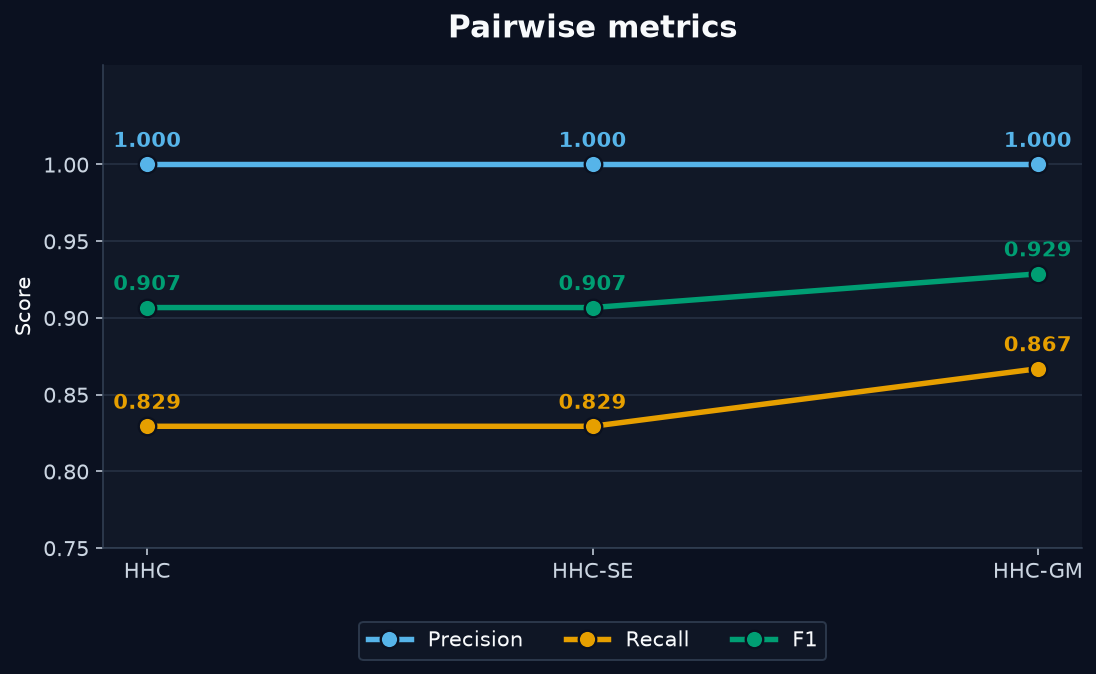

In [39]:
metric_line_plot(
    ["pairwise_precision", "pairwise_recall", "pairwise_f1"],
    ["Precision", "Recall", "F1"],
    "Pairwise metrics",
    "pairwise_metrics.png",
)

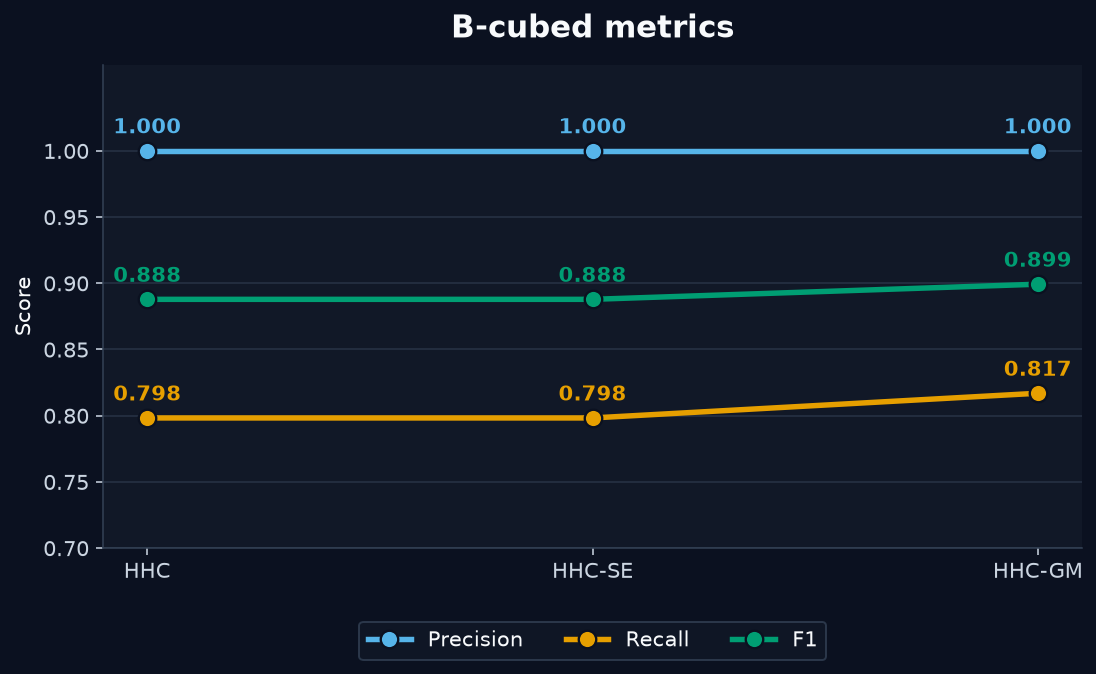

In [40]:
metric_line_plot(
    ["b3_precision", "b3_recall", "b3_f1"],
    ["Precision", "Recall", "F1"],
    "B-cubed metrics",
    "bcubed_metrics.png",
)

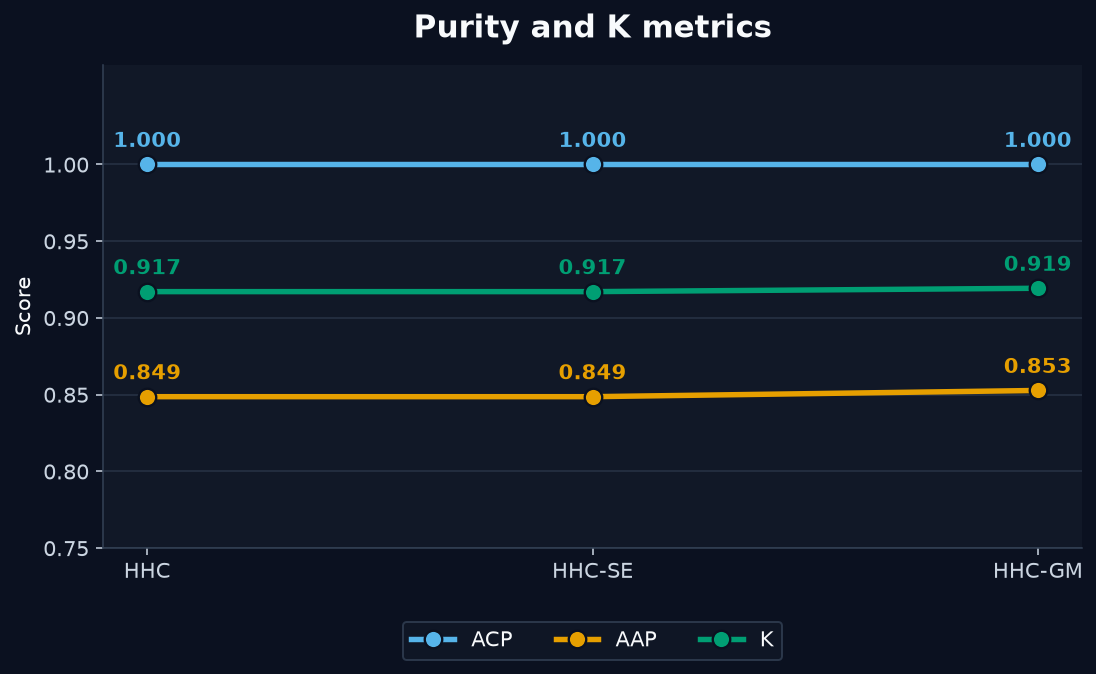

In [41]:
metric_line_plot(
    ["average_cluster_purity", "average_author_purity", "k_metric"],
    ["ACP", "AAP", "K"],
    "Purity and K metrics",
    "purity_k_metrics.png",
)

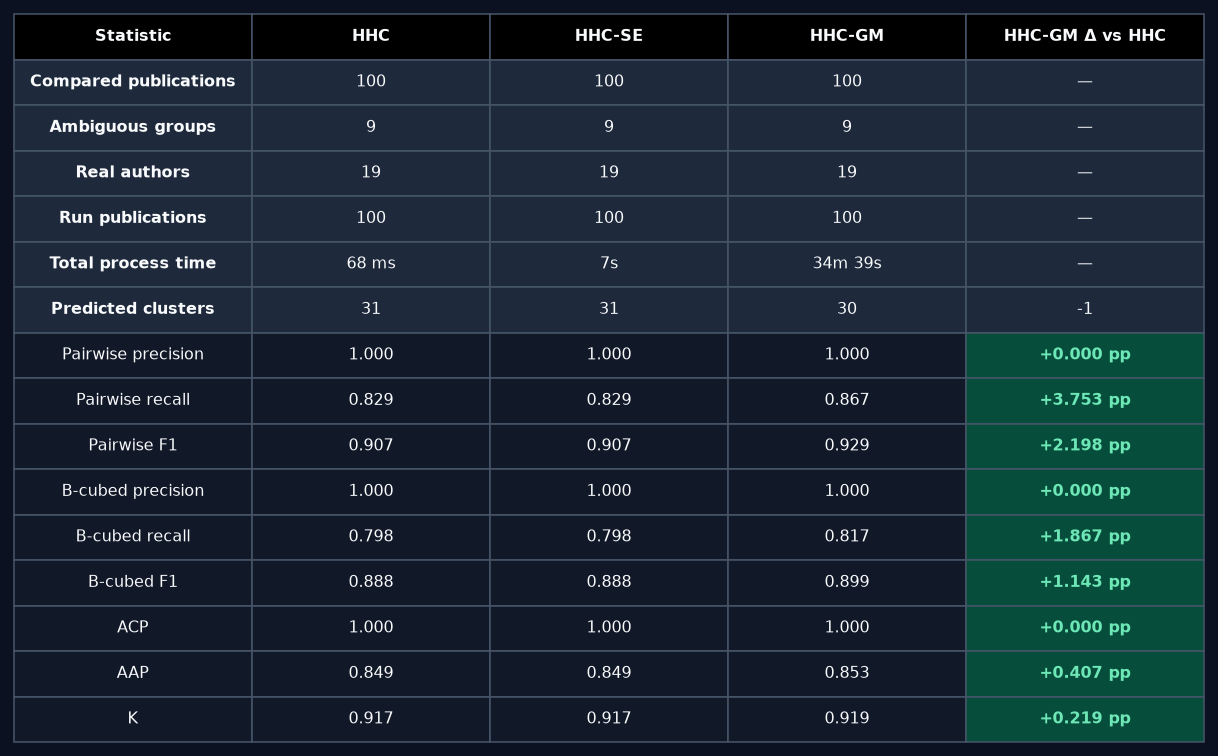

In [42]:
metrics = [
    ("Pairwise precision", "pairwise_precision"),
    ("Pairwise recall", "pairwise_recall"),
    ("Pairwise F1", "pairwise_f1"),
    ("B-cubed precision", "b3_precision"),
    ("B-cubed recall", "b3_recall"),
    ("B-cubed F1", "b3_f1"),
    ("ACP", "average_cluster_purity"),
    ("AAP", "average_author_purity"),
    ("K", "k_metric"),
]

def format_duration(seconds):
    if seconds < 1:
        return f"{round(seconds * 1_000):,} ms"
    total_seconds = round(seconds)
    hours, remainder = divmod(total_seconds, 3_600)
    minutes, whole_seconds = divmod(remainder, 60)
    if hours:
        return f"{hours}h {minutes}m {whole_seconds}s"
    if minutes:
        return f"{minutes}m {whole_seconds}s"
    return f"{whole_seconds}s"


publication_count = len(common)
group_count = common["ambiguous_name"].nunique()
summary_rows = [
    ["Compared publications", *[f"{publication_count:,}" for _ in METHODS], "—"],
    ["Ambiguous groups", *[f"{group_count:,}" for _ in METHODS], "—"],
    ["Real authors", *[f"{scores[method]['true_authors']:,}" for method in METHODS], "—"],
    ["Run publications", *[f"{run_summaries[method]['records']:,}" for method in METHODS], "—"],
    ["Total process time", *[format_duration(run_summaries[method]["runtime_seconds"]) for method in METHODS], "—"],
    [
        "Predicted clusters",
        *[f"{scores[method]['predicted_clusters']:,}" for method in METHODS],
        f"{scores['HHC-GM']['predicted_clusters'] - scores['HHC']['predicted_clusters']:+,}",
    ],
]
table_rows = list(summary_rows)
changes = []
for label, key in metrics:
    values = [scores[method][key] for method in METHODS]
    change = (scores["HHC-GM"][key] - scores["HHC"][key]) * 100
    changes.append(change)
    table_rows.append([label, *[f"{value:.3f}" for value in values], f"{change:+.3f} pp"])

fig, axis = plt.subplots(figsize=(8.5, 5.2), facecolor=BACKGROUND)
axis.axis("off")
table = axis.table(
    cellText=table_rows,
    colLabels=["Statistic", *METHODS, "HHC-GM Δ vs HHC"],
    colLoc="center",
    cellLoc="center",
    bbox=[0, 0, 1, 1],
)
table.auto_set_font_size(False)
table.set_fontsize(8)

for cell in table.get_celld().values():
    cell.set_facecolor(PANEL)
    cell.set_edgecolor("#475569")
    cell.set_linewidth(0.8)
    cell.set_text_props(color=TEXT)
for column in range(5):
    table[(0, column)].set_facecolor("#000000")
    table[(0, column)].set_text_props(color=TEXT, fontweight="bold")
for row in range(1, len(summary_rows) + 1):
    for column in range(5):
        table[(row, column)].set_facecolor("#1E293B")
    table[(row, 0)].set_text_props(color=TEXT, fontweight="bold")
for row, change in enumerate(changes, start=len(summary_rows) + 1):
    table[(row, 4)].set_facecolor("#064E3B" if change >= 0 else "#7F1D1D")
    table[(row, 4)].set_text_props(color="#6EE7B7" if change >= 0 else "#FCA5A5", fontweight="bold")

fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.savefig(report_dir / "reports_table.png", bbox_inches="tight", pad_inches=0, facecolor=fig.get_facecolor())
plt.show()
plt.close()